This document is meant to test the discretization invariance of the 2D Fourier neural operator on a heat equation dataset. Unlike the first FNO2D_CDE, this model does not subsample a single larger dataset; initial conditions were generated and subsampled for each wanted resolution, then evolved in time separately to reach different initial conditions.

Loading high-res dataset: /scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N512_multi.h5
Loaded: 1000 samples at resolution N=512
Evaluating N=32  (factor=16)
N=32 | mean=1.7034e-02 | std=5.1120e-03
Evaluating N=64  (factor=8)
N=64 | mean=1.6720e-02 | std=5.0549e-03
Evaluating N=128  (factor=4)
N=128 | mean=1.6720e-02 | std=5.0616e-03
Evaluating N=256  (factor=2)
N=256 | mean=1.6719e-02 | std=5.0663e-03
Evaluating N=512  (factor=1)
N=512 | mean=1.6719e-02 | std=5.0680e-03


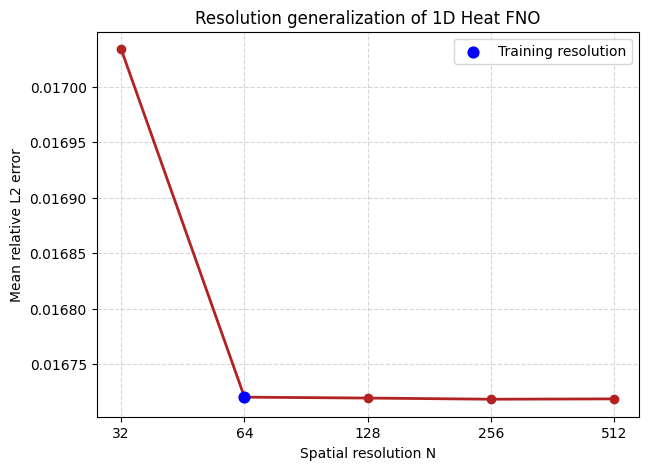

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
from FNO1D_def import *
from utilities3 import LpLoss          

# ================================================================
# Config
# ================================================================
modes = 4
width = 64

model_path = f"/scratch/mnhagen/models/burgers/with_spatial/FNO1D_heat_eq_128_modes{modes}.pt"
highres_path = "/scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N512_multi.h5"

# resolutions to test (these must divide the high-res grid)
resolutions = [32, 64, 128, 256, 512]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

myloss = LpLoss(size_average=True)

# ================================================================
# Load high-resolution dataset (fixed ICs, two-frame trajectories)
# ================================================================
print("Loading high-res dataset:", highres_path)

with h5py.File(highres_path, "r") as f:
    # shape (num_samples, T, N) — but we stored only 2 frames (t=0,t=T)
    U_full = f["u"][:]                    # (samples, 2, N)
    X_full = f["X"][:]                    # (N,)
    
num_samples, _, N_high = U_full.shape
print(f"Loaded: {num_samples} samples at resolution N={N_high}")

# split u0, uT
u0_full = U_full[:, 0, :]     # (M, N_high)
uT_full = U_full[:, 1, :]     # (M, N_high)

# convert to torch
u0_full = torch.tensor(u0_full, dtype=torch.float32)
uT_full = torch.tensor(uT_full, dtype=torch.float32)

# ================================================================
# Helper: anti-aliased downsampling (1D)
# ================================================================
def downsample_aa(u, factor):
    """
    u: tensor shape (M, N)
    factor: integer divisor of N

    Returns: (M, N//factor)
    """
    if factor == 1:
        return u

    u_np = u.numpy()
    M, N = u_np.shape
    cutoff = N // (2 * factor)

    out_list = []
    for i in range(M):
        u_i = u_np[i]
        u_ft = np.fft.rfft(u_i)
        out_ft = np.zeros_like(u_ft)
        out_ft[:cutoff] = u_ft[:cutoff]
        u_filt = np.fft.irfft(out_ft, n=N)
        out_list.append(u_filt[::factor])

    return torch.tensor(np.array(out_list), dtype=torch.float32)

# ================================================================
# Evaluate the FNO at a given resolution
# ================================================================
def evaluate_resolution(model, u0_full, uT_full, factor, batch_size=20):
    """
    Downsample u0 → feed to model → compare to downsampled uT.
    """
    # downsample both frames
    u0 = downsample_aa(u0_full, factor)   # (M, N_sub)
    uT = downsample_aa(uT_full, factor)   # (M, N_sub)

    M, N_sub = u0.shape
    print(f"Evaluating N={N_sub}  (factor={factor})")

    dataset = torch.utils.data.TensorDataset(u0, uT)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    per_sample_losses = []

    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)        # (B, N)
            yb = yb.to(device)        # (B, N)

            # ---- FNO input format (match training) ----
            xb = xb.unsqueeze(1)               # (B,1,N)
            u = xb.permute(0, 2, 1)            # (B,N,1)
            grid = model.get_grid(u.shape, device)
            inp = torch.cat([u, grid], dim=-1) # (B,N,2)

            pred = model(inp)                  # (B,N,1)
            pred = pred.permute(0,2,1)         # → (B,1,N)
            pred = pred.squeeze(1)             # → (B,N)

            # compute loss per sample
            for i in range(pred.size(0)):
                li = myloss(pred[i:i+1], yb[i:i+1]).item()
                per_sample_losses.append(li)

    per_sample_losses = np.array(per_sample_losses)
    return per_sample_losses.mean(), per_sample_losses.std(), N_sub

# ================================================================
# Main loop
# ================================================================
# Load trained model
model = FNO1D(modes, width).to(device)
model.fc1 = torch.nn.Linear(width, 1).to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

results = []

for N in resolutions:
    factor = N_high // N
    mean_l2, std_l2, N_eval = evaluate_resolution(model, u0_full, uT_full, factor)
    print(f"N={N_eval} | mean={mean_l2:.4e} | std={std_l2:.4e}")
    results.append((N_eval, mean_l2, std_l2))

# ================================================================
# Plotting
# ================================================================
Ns, means, stds = zip(*results)

plt.figure(figsize=(7,5))
plt.plot(Ns, means, 'o-', lw=2, color = "firebrick")
plt.xscale("log", base=2)
plt.xticks(Ns, [str(n) for n in Ns])
plt.xlabel("Spatial resolution N")
plt.ylabel("Mean relative L2 error")
plt.title("Resolution generalization of 1D Heat FNO")
plt.scatter(64, means[1], color='blue', s=60, zorder=5, label='Training resolution')
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.show()


In [6]:
import glob

def plot_across_resolutions_1D(model, folder, sample_idx, device, display_worst=False):
    # sort by resolution in the filename "*_autoreg_N{N}_multi.h5"
    paths = sorted(
        glob.glob(folder + "/heat1D_autoreg_N*_multi.h5"),
        key=lambda p: int(p.split("_autoreg_N")[1].split("_")[0])
    )

    # ---------- helper to run model and compute MSE ----------
    def mse_for_sample(h5_path, idx):
        with h5py.File(h5_path, "r") as f:
            U = f["u"][:]      # shape (num_samples, 2, N)
        u0 = U[idx, 0]
        uT = U[idx, 1]
        # build input tensor
        u0_t = torch.tensor(u0[None, None, :], dtype=torch.float32, device=device)  # (B=1, C=1, N)
        u0_t = u0_t.permute(0, 2, 1)   # (1, N, 1)
        grid = model.get_grid(u0_t.shape, device)  # (1, N, 1) or similar
        inp = torch.cat([u0_t, grid], dim=-1).to(device)  # (1, N, 2)
        with torch.no_grad():
            pred = model(inp).permute(0, 2, 1).squeeze(0).squeeze(0).cpu().numpy()
        # MSE
        return float(np.mean((pred - uT) ** 2))

    # ---------- optionally find worst sample index ----------
    if display_worst:
        # determine dataset size from the first file
        with h5py.File(paths[0], "r") as f:
            num_samples = f["u"].shape[0]

        model.eval()
        worst_idx, worst_avg_mse = None, -1.0

        # loop over all samples and average MSE across all resolutions
        for idx in range(num_samples):
            mses = []
            for p in paths:
                mses.append(mse_for_sample(p, idx))
            avg_mse = float(np.mean(mses))
            if avg_mse > worst_avg_mse:
                worst_avg_mse = avg_mse
                worst_idx = idx

        sample_idx = worst_idx
        print(f"[display_worst] Selected sample index {sample_idx} with avg MSE={worst_avg_mse:.4e}")

    # ---------- plotting for the chosen sample_idx ----------
    model.eval()


plot_across_resolutions_1D(model, 
                           folder = "/scratch/mnhagen/datasets/heat1d_multires", 
                           sample_idx = 990,
                            device = device,
                            display_worst= True)

[display_worst] Selected sample index 980 with avg MSE=3.4644e-04



File: /scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N32_multi.h5


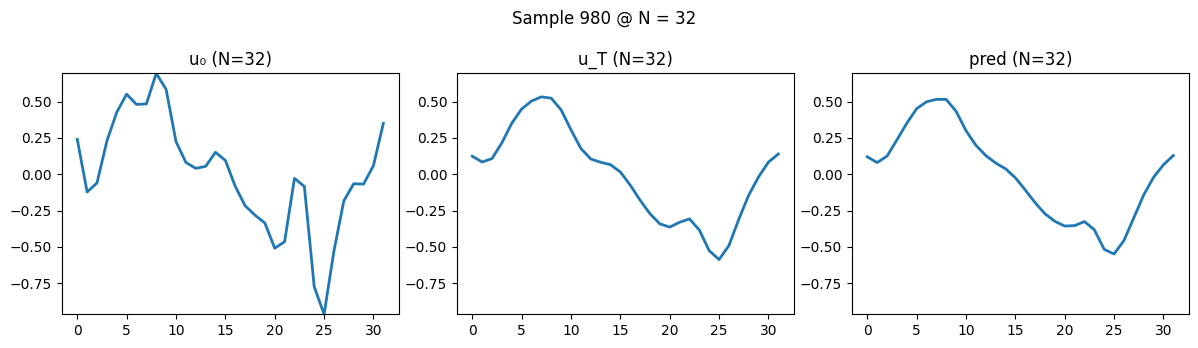

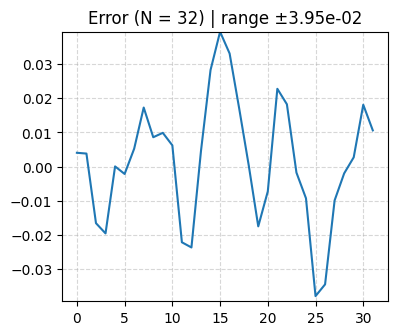


File: /scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N64_multi.h5


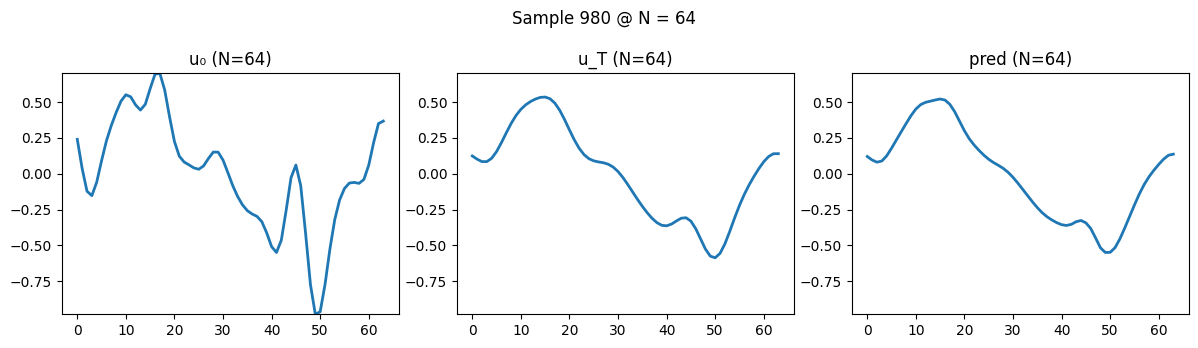

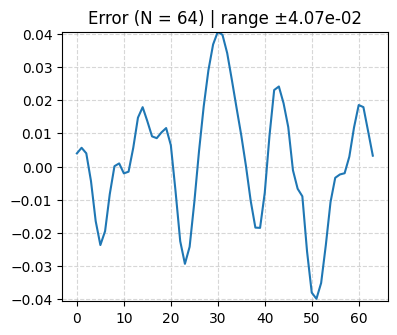


File: /scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N128_multi.h5


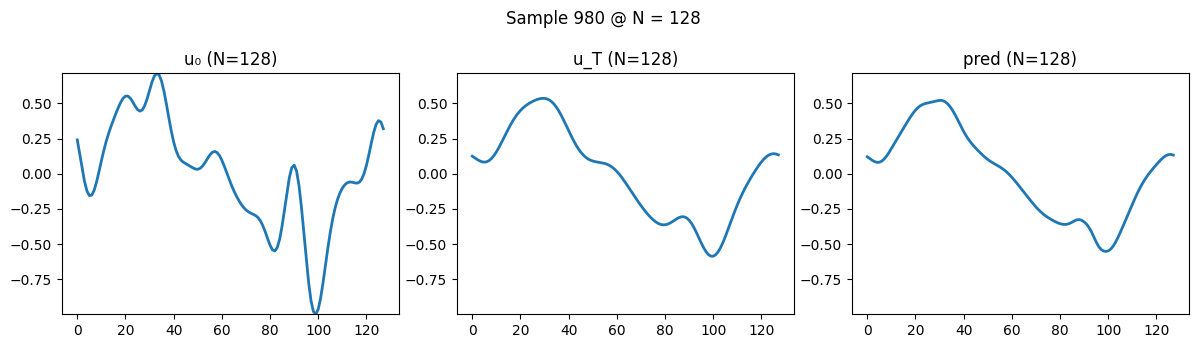

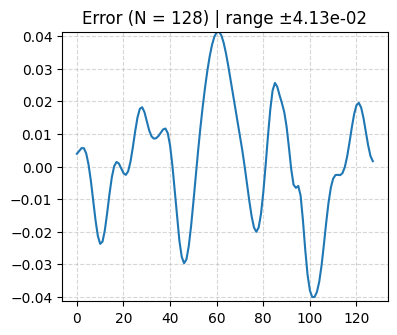


File: /scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N256_multi.h5


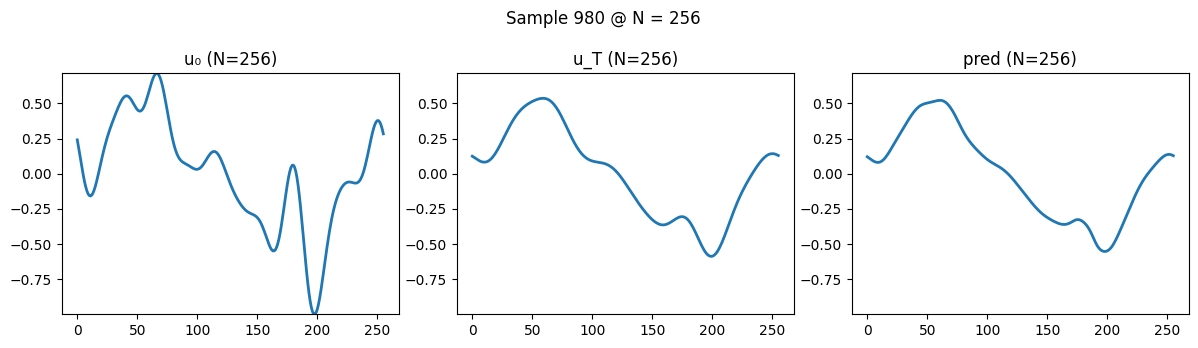

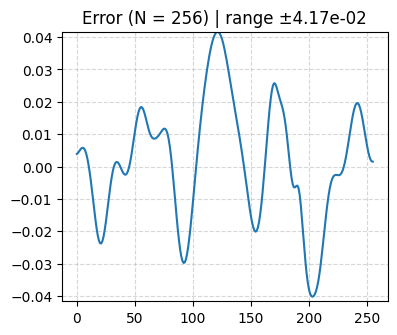


File: /scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N512_multi.h5


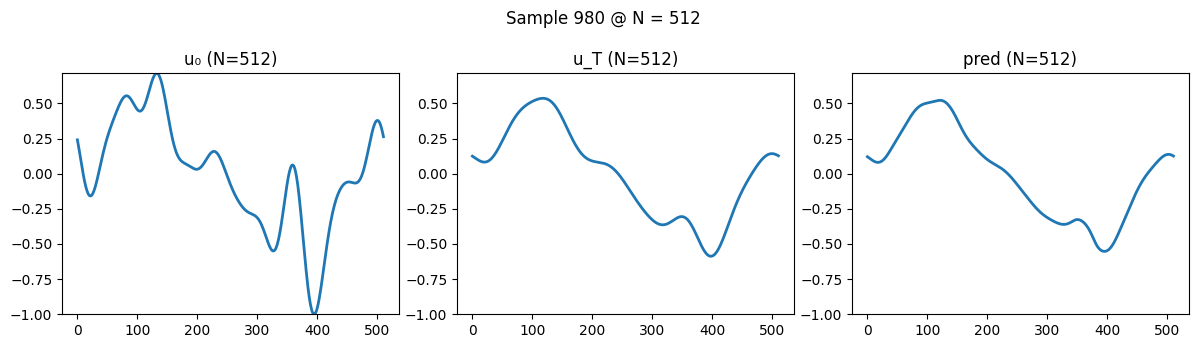

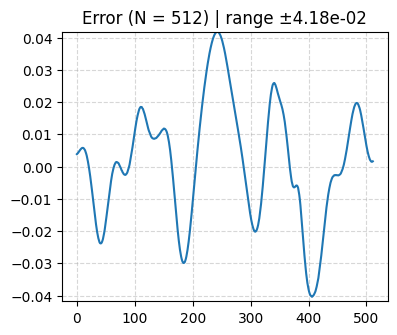

In [8]:
import glob 

def plot_across_resolutions_1D(model, folder, sample_idx, device, display_worst=False):

    paths = sorted(
        glob.glob(folder + "/heat1D_autoreg_N*_multi.h5"),
        key=lambda p: int(p.split("_autoreg_N")[1].split("_")[0])
    )

    model.eval()

    for p in paths:
        print("\nFile:", p)

        with h5py.File(p, "r") as f:
            U = f["u"][:]     # shape: (num_samples, 2, N)

        u0 = U[sample_idx, 0]
        uT = U[sample_idx, 1]
        N = u0.shape[0]

        # --- build model input ---
        u0_t = torch.tensor(u0[None], dtype=torch.float32)   # (1, N)
        u0_t = u0_t.unsqueeze(1)                             # (1, 1, N)
        u0_t = u0_t.permute(0, 2, 1)                         # (1, N, 1)
        u0_t = u0_t.to(device)

        grid = model.get_grid(u0_t.shape, device)
        inp = torch.cat([u0_t, grid], dim=-1).to(device)

        # --- forward pass ---
        with torch.no_grad():
            pred = model(inp)                   # (1, N, 1)
            pred = pred.permute(0, 2, 1)        # (1, 1, N)
            pred = pred.squeeze(0).squeeze(0).cpu().numpy()

        # --- plotting ---
        u0_np = u0
        uT_np = uT
        pr_np = pred
        diff = uT_np - pr_np

        vmin = min(u0_np.min(), uT_np.min(), pr_np.min())
        vmax = max(u0_np.max(), uT_np.max(), pr_np.max())

        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
        labels = [f"u₀ (N={N})", f"u_T (N={N})", f"pred (N={N})"]

        for ax, arr, ttl in zip(axes, [u0_np, uT_np, pr_np], labels):
            ax.plot(arr, lw=2)
            ax.set_ylim(vmin, vmax)
            ax.set_title(ttl)

        plt.suptitle(f"Sample {sample_idx} @ N = {N}")
        plt.tight_layout()
        plt.show()

        # --- error plot ---
        m = np.abs(diff).max()
        plt.figure(figsize=(4.2, 3.5))
        plt.plot(diff)
        plt.ylim(-m, m)
        plt.title(f"Error (N = {N}) | range ±{m:.2e}")
        plt.grid(True, ls="--", alpha=0.5)
        plt.show()


# Example call
plot_across_resolutions_1D(
    model,
    folder="/scratch/mnhagen/datasets/heat1d_multires",
    sample_idx=980,
    device=device
)
